To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File paths dictionary (update if using different paths or names)
file_paths = {
    'hashmith': '/content/hashmith.csv',
    'mokesh': '/content/mokesh.csv',
    'mukesh_raja': '/content/mukesh_raja.csv',
    'surya': '/content/surya.csv',
    'swaroop': '/content/swaroop.csv'
}

# Load datasets
datasets = {}
for name, path in file_paths.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower()  # Normalize column names
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
    df = df.dropna(subset=['date', 'amount'])
    datasets[name] = df


<ipython-input-2-68de5fc2187e>:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
<ipython-input-2-68de5fc2187e>:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
<ipython-input-2-68de5fc2187e>:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
<ipython-input-2-68de5fc2187e>:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is 

In [11]:
#Transaction by Each Person
print("🔍  Transaction by Each Person:\n")
for name, df in datasets.items():
    max_row = df[df['amount'] == df['amount'].max()]
    print(f"{name.upper()}:\n{max_row[['date', 'amount', 'detail']]}\n")


🔍  Transaction by Each Person:

HASHMITH:
                   date   amount  detail
418 2023-07-17 16:09:00  25000.0  Myntra

MOKESH:
          date  amount   detail
222 2023-10-04  7500.0  Netflix

MUKESH_RAJA:
                   date   amount          detail
334 2023-10-07 01:29:00  51000.0  k-block cateen

SURYA:
                   date   amount      detail
202 2024-07-17 21:15:00  32000.0  BookMyShow

SWAROOP:
                   date   amount  detail
298 2024-07-08 10:18:00  48500.0  Zomato



In [12]:

# Group by 'person' and 'detail', then sum the amounts
grouped = combined_df.groupby(['person', 'detail'])['amount'].sum().reset_index()
# Sort for better readability
grouped = grouped.sort_values(by=['person', 'amount'], ascending=[True, False])
# Print individual summaries
for person in grouped['person'].unique():
    print(f"\n--- {person} ---")
    person_data = grouped[grouped['person'] == person]
    for _, row in person_data.iterrows():
        print(f"{row['detail']}: ₹{row['amount']:.2f}")



--- hashmith ---
Myntra: ₹32824.75
IRCTC: ₹11825.00
Flipkart: ₹10214.00
Amazon: ₹7211.00
Swiggy: ₹4961.00
Zomato: ₹1895.84
Uber: ₹1737.00
enzo shop: ₹1510.00
Spotify: ₹1419.00
Hotstar: ₹1130.00
aunty mess: ₹1070.00
Ola: ₹794.00
k-block cateen: ₹735.00
DTH recharges: ₹531.00
BookMyShow: ₹520.00
m-block cateen: ₹507.00
Netflix: ₹160.00

--- mokesh ---
aunty mess: ₹104791.50
IRCTC: ₹81842.04
Amazon: ₹39800.51
Myntra: ₹30283.55
Zomato: ₹28240.08
Flipkart: ₹24761.12
k-block cateen: ₹22581.00
Swiggy: ₹22363.50
BookMyShow: ₹19209.00
Hotstar: ₹18133.08
enzo shop: ₹16891.55
Uber: ₹15027.50
DTH recharges: ₹14284.25
Spotify: ₹14204.10
m-block cateen: ₹12285.80
Netflix: ₹11979.00
Ola: ₹11161.00

--- mukesh_raja ---
k-block cateen: ₹142681.73
m-block cateen: ₹90532.32
enzo shop: ₹84397.54
aunty mess: ₹70671.21
Amazon: ₹69073.00
BookMyShow: ₹63391.00
Myntra: ₹41069.00
Flipkart: ₹24470.00
IRCTC: ₹18757.00
Swiggy: ₹18157.00
Zomato: ₹16101.00
Uber: ₹14280.00
Hotstar: ₹13686.00
DTH recharges: ₹11899.55

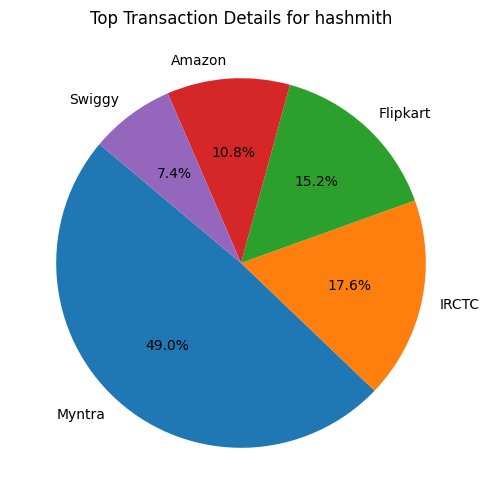

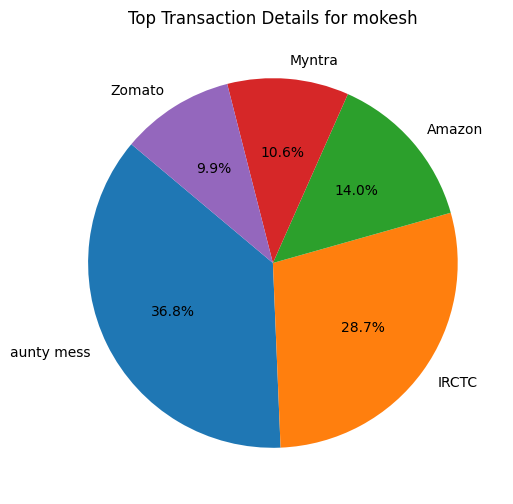

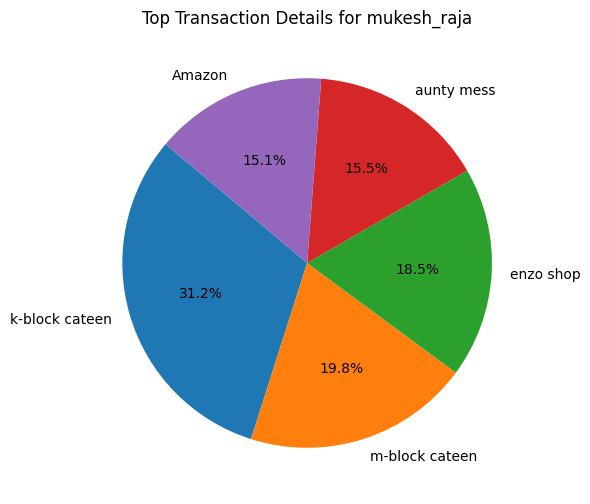

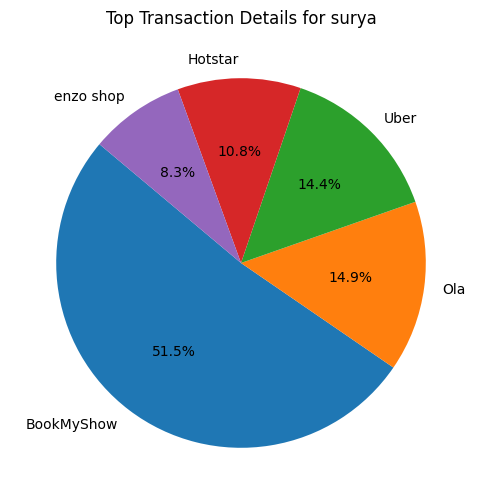

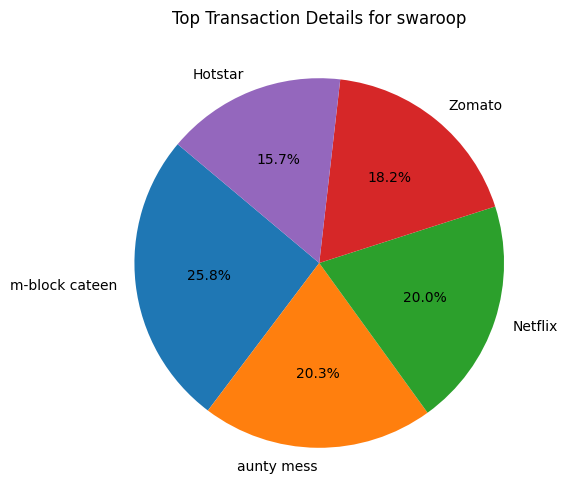

In [13]:
#pie chart of top Transcation

for name, df in datasets.items():
    top_details = df.groupby('detail')['amount'].sum().sort_values(ascending=False).head(5)
    plt.figure(figsize=(6, 6))
    top_details.plot(kind='pie', autopct='%1.1f%%', startangle=140)
    plt.title(f'Top Transaction Details for {name}')
    plt.ylabel('')
    plt.show()



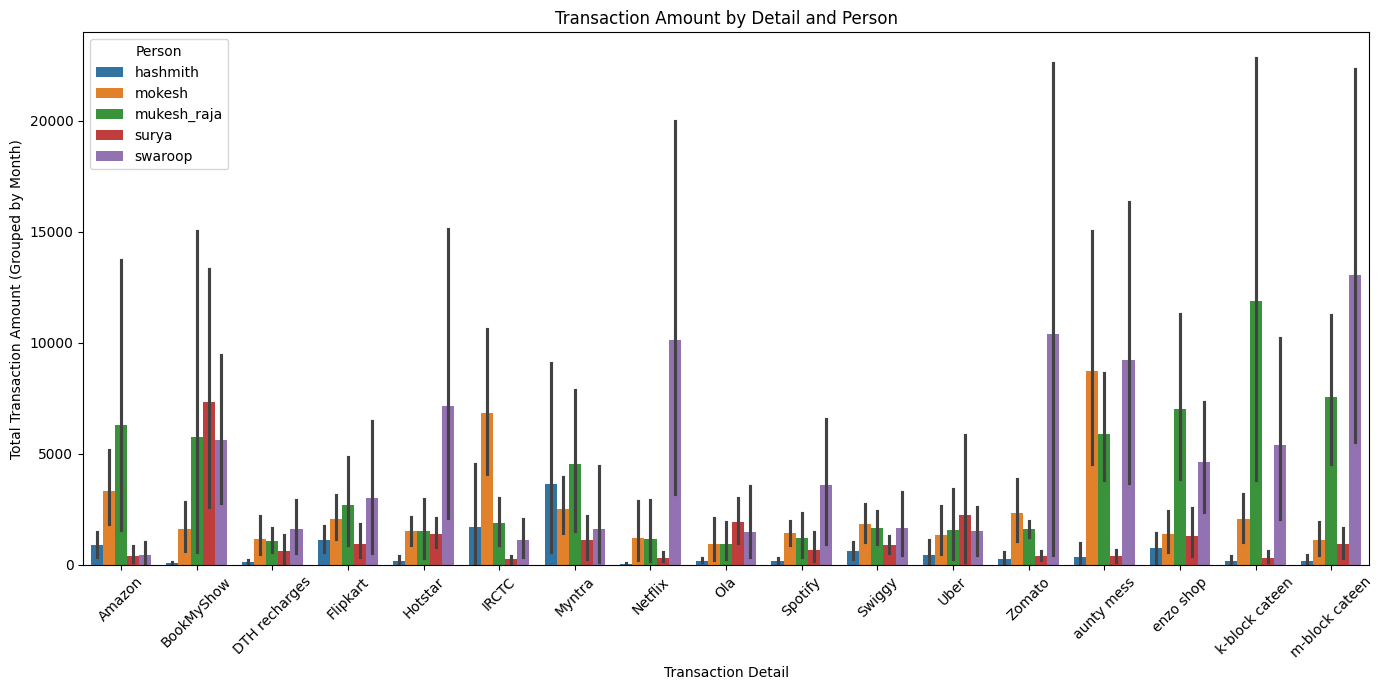

In [14]:
#transcation Amount by detail and Person(graph)

import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Combine all datasets and add 'person' column
combined_list = []
for name, df in datasets.items():
    df['person'] = name
    df['month'] = df['date'].dt.strftime('%B')  # Month name
    combined_list.append(df)

combined_df = pd.concat(combined_list, ignore_index=True)

# Step 2: Group by month, detail, and person, summing amounts
grouped = combined_df.groupby(['month', 'detail', 'person'])['amount'].sum().reset_index()

# Step 3: Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=grouped, x='detail', y='amount', hue='person')

plt.title("Transaction Amount by Detail and Person")
plt.xlabel("Transaction Detail")
plt.ylabel("Total Transaction Amount (Grouped by Month)")
plt.xticks(rotation=45)
plt.legend(title="Person")
plt.tight_layout()
plt.show()




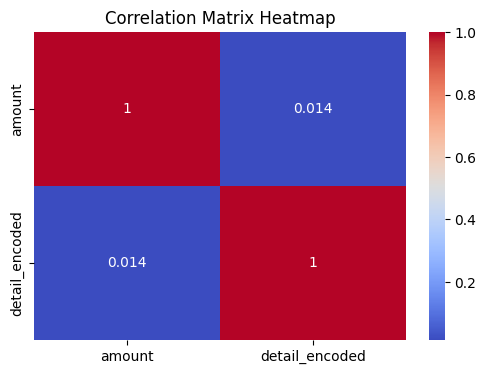

In [7]:

#Correlation matrix(heap map)
# Combine datasets
combined = pd.concat(datasets.values(), ignore_index=True)

# Encode 'detail' as numeric
combined['detail_encoded'] = combined['detail'].astype('category').cat.codes

# Correlation matrix
corr = combined[['amount', 'detail_encoded']].corr()

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


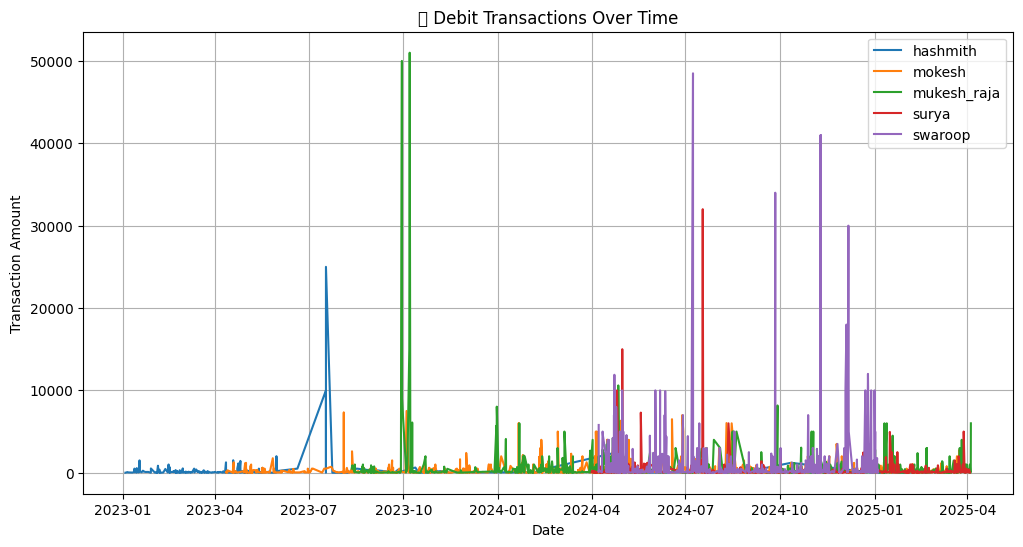

In [ ]:
plt.figure(figsize=(12, 6))
for name, df in datasets.items():
    df_sorted = df.sort_values('date')
    plt.plot(df_sorted['date'], df_sorted['amount'], label=name)
plt.title("📈 Debit Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Transaction Amount")
plt.legend()
plt.grid(True)
plt.show()


<ipython-input-14-25cbfe0f07c7>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  person_month['month_num'] = person_month['month'].apply(lambda x: month_order.index(x))


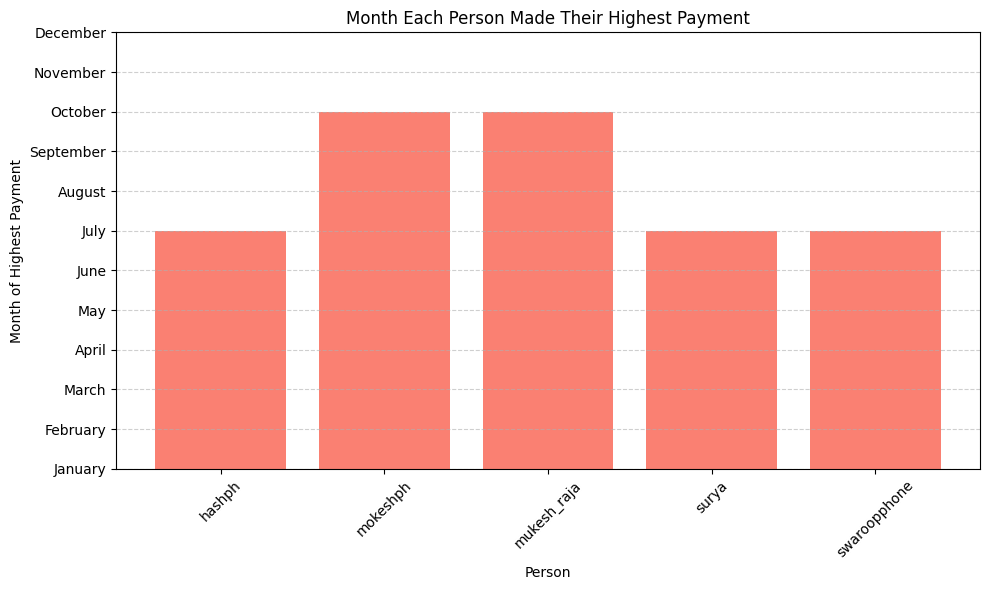

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'date' is in datetime format
combined_df['date'] = pd.to_datetime(combined_df['date'])

# Add 'month' column (as full month name)
combined_df['month'] = combined_df['date'].dt.month_name()

# Get the row with the highest payment per person
top_txn = combined_df.loc[combined_df.groupby('person')['amount'].idxmax()]

# Extract person and month of highest transaction
person_month = top_txn[['person', 'month']]

# For plotting, we need to map months to numbers for y-axis ordering
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
person_month['month_num'] = person_month['month'].apply(lambda x: month_order.index(x))

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(person_month['person'], person_month['month_num'], color='salmon')
plt.xlabel("Person")
plt.ylabel("Month of Highest Payment")
plt.title("Month Each Person Made Their Highest Payment")
plt.yticks(ticks=range(12), labels=month_order)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


<ipython-input-16-f53fd097b535>:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1_per_person = combined_df.groupby('person').apply(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

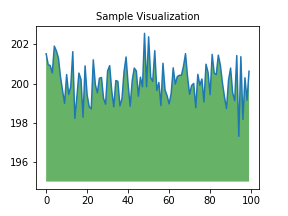

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning Crash Course

<div>

These are a few of the notebooks from Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Linear regression with tf.keras using synthetic data](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [TensorFlow with GPUs](/notebooks/gpu.ipynb)
- [TPUs in Colab](/notebooks/tpu.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Retraining an Image Classifier](https://tensorflow.org/hub/tutorials/tf2_image_retraining): Build a Keras model on top of a pre-trained image classifier to distinguish flowers.
- [Text Classification](https://tensorflow.org/hub/tutorials/tf2_text_classification): Classify IMDB movie reviews as either *positive* or *negative*.
- [Style Transfer](https://tensorflow.org/hub/tutorials/tf2_arbitrary_image_stylization): Use deep learning to transfer style between images.
- [Multilingual Universal Sentence Encoder Q&A](https://tensorflow.org/hub/tutorials/retrieval_with_tf_hub_universal_encoder_qa): Use a machine learning model to answer questions from the SQuAD dataset.
- [Video Interpolation](https://tensorflow.org/hub/tutorials/tweening_conv3d): Predict what happened in a video between the first and the last frame.
